# 05 — A/B Test Design & Simulation
**Citi Bike Demand Forecasting & A/B Testing Framework**

**Experiment:**  
Does ML-optimized rebalancing improve dock availability vs the current heuristic?

**Design:**
- Unit of randomization: station cluster (not individual station — avoids SUTVA violations)
- Treatment: XGBoost-informed rebalancing schedule
- Control: current heuristic (demand-blind) schedule
- Primary metric: dock availability rate (% of hours with ≥1 bike available)
- Test period: 31 days (March 2024 simulation)

**Analyses:**
1. Power analysis — required sample size
2. Simulate A/B outcomes
3. Frequentist: Welch t-test + Mann-Whitney U
4. Sequential testing: O'Brien-Fleming boundaries
5. Bayesian: PyMC posterior on uplift

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.experiments.power_analysis import compute_sample_size, power_curve, sample_size_table
from src.experiments.ab_test import (
    assign_clusters, simulate_outcomes,
    run_ttest, run_mannwhitney, run_sequential_test,
)
from src.experiments.bayesian_ab import run_bayesian_ab

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

PROCESSED_DIR = Path('../data/processed')

# Experiment parameters
BASELINE_AVAILABILITY = 0.75   # 75% dock availability in control
TRUE_LIFT             = 0.08   # 8pp true treatment effect (simulated)
NOISE_STD             = 0.05
ALPHA                 = 0.05
POWER                 = 0.80
N_DAYS                = 31

## 1. Load Cluster Assignments

In [2]:
clusters = pd.read_parquet(PROCESSED_DIR / 'station_clusters.parquet')

# Drop the tiny noise cluster (< 10 stations)
cluster_sizes = clusters['kmeans_cluster'].value_counts()
valid_clusters = cluster_sizes[cluster_sizes >= 10].index.tolist()
clusters = clusters[clusters['kmeans_cluster'].isin(valid_clusters)].reset_index(drop=True)

print(f'Stations in experiment: {len(clusters):,}')
print(f'Clusters: {sorted(valid_clusters)}')
print(cluster_sizes[valid_clusters].sort_index().rename('n_stations'))

Stations in experiment: 2,266
Clusters: [0, 1, 3]
kmeans_cluster
0    1330
1     120
3     816
Name: n_stations, dtype: int64


## 2. Power Analysis

In [3]:
# Required station-days per group for various MDEs
mde_values = [0.03, 0.05, 0.08, 0.10]
table = sample_size_table(BASELINE_AVAILABILITY, mde_values, alpha_values=[0.05, 0.01], power=POWER)

print(f'Required station-days per group (baseline={BASELINE_AVAILABILITY}, power={POWER})\n')
print(f'{"MDE":>8}  {"α=0.05":>10}  {"α=0.01":>10}')
for mde in mde_values:
    print(f'{mde:>8.0%}  {table[(mde, 0.05)]:>10,}  {table[(mde, 0.01)]:>10,}')

# Required n for our experiment
req_n = compute_sample_size(BASELINE_AVAILABILITY, TRUE_LIFT, ALPHA, POWER)
available_n = len(clusters) * N_DAYS // 2  # approx station-days per group
print(f'\nFor MDE={TRUE_LIFT:.0%}: need {req_n:,} station-days per group')
print(f'Available (est.): {available_n:,} station-days per group')
print(f'Powered: {available_n >= req_n}')

Required station-days per group (baseline=0.75, power=0.8)

     MDE      α=0.05      α=0.01
      3%       3,133       4,662
      5%       1,092       1,625
      8%         404         601
     10%         248         369

For MDE=8%: need 404 station-days per group
Available (est.): 35,123 station-days per group
Powered: True


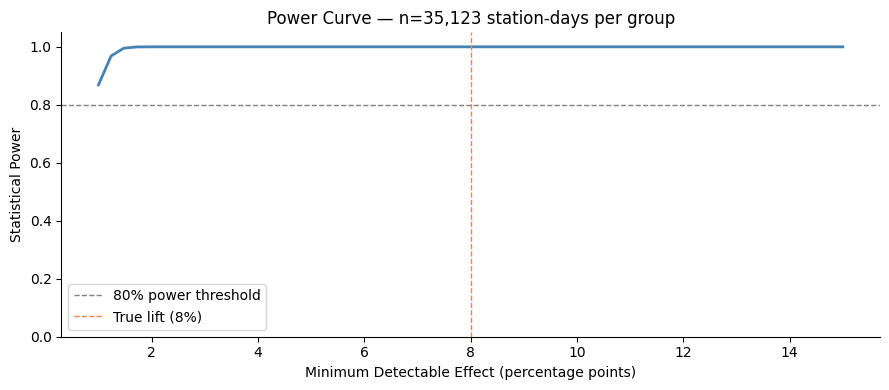

In [4]:
# Power curve — achieved power vs MDE at our available sample size
mde_range = np.linspace(0.01, 0.15, 60)
powers = power_curve(BASELINE_AVAILABILITY, mde_range, n_per_group=available_n, alpha=ALPHA)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mde_range * 100, powers, color='steelblue', linewidth=2)
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80% power threshold')
ax.axvline(TRUE_LIFT * 100, color='coral', linestyle='--', linewidth=1,
           label=f'True lift ({TRUE_LIFT:.0%})')
ax.set_title(f'Power Curve — n={available_n:,} station-days per group')
ax.set_xlabel('Minimum Detectable Effect (percentage points)')
ax.set_ylabel('Statistical Power')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Cluster Randomization

In [5]:
cluster_assignments = assign_clusters(valid_clusters, random_state=42)
print('Cluster assignments:')
for c, group in sorted(cluster_assignments.items()):
    n = cluster_sizes[c]
    print(f'  Cluster {c} ({n:,} stations) → {group}')

# Map to station level
clusters['group'] = clusters['kmeans_cluster'].map(cluster_assignments)

Cluster assignments:
  Cluster 0 (1,330 stations) → treatment
  Cluster 1 (120 stations) → control
  Cluster 3 (816 stations) → treatment


## 4. Simulate A/B Outcomes

In [6]:
outcomes = simulate_outcomes(
    station_clusters=clusters,
    cluster_assignments=cluster_assignments,
    n_days=N_DAYS,
    baseline_availability=BASELINE_AVAILABILITY,
    true_lift=TRUE_LIFT,
    noise_std=NOISE_STD,
    random_state=42,
)

print(f'Simulated outcomes: {len(outcomes):,} station-days')
print(outcomes.groupby('group')['availability_rate'].agg(['count', 'mean', 'std']).round(4))

Simulated outcomes: 70,246 station-days
           count    mean     std
group                           
control     3720  0.7506  0.0502
treatment  66526  0.8300  0.0501


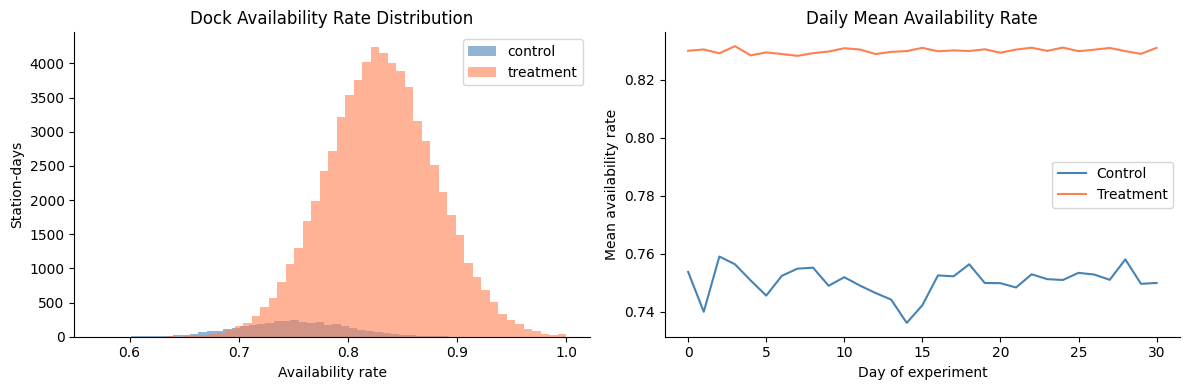

In [7]:
# Distribution of availability rates by group
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for group, color in [('control', 'steelblue'), ('treatment', 'coral')]:
    g = outcomes[outcomes['group'] == group]['availability_rate']
    axes[0].hist(g, bins=50, alpha=0.6, color=color, label=group, edgecolor='none')

axes[0].set_title('Dock Availability Rate Distribution')
axes[0].set_xlabel('Availability rate')
axes[0].set_ylabel('Station-days')
axes[0].legend()

# Daily mean by group
daily = outcomes.groupby(['day', 'group'])['availability_rate'].mean().unstack()
daily['control'].plot(ax=axes[1], color='steelblue', label='Control', linewidth=1.5)
daily['treatment'].plot(ax=axes[1], color='coral', label='Treatment', linewidth=1.5)
axes[1].set_title('Daily Mean Availability Rate')
axes[1].set_xlabel('Day of experiment')
axes[1].set_ylabel('Mean availability rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Frequentist Tests

In [8]:
ttest_result = run_ttest(outcomes)
mw_result    = run_mannwhitney(outcomes)

print('=== Welch t-test ===')
for k, v in ttest_result.items():
    print(f'  {k}: {v}')

print('\n=== Mann-Whitney U ===')
for k, v in mw_result.items():
    print(f'  {k}: {v}')

=== Welch t-test ===
  test: Welch t-test
  statistic: 93.7661
  p_value: 0.0
  mean_control: 0.7506
  mean_treatment: 0.83
  observed_lift: 0.0794
  significant_at_05: True

=== Mann-Whitney U ===
  test: Mann-Whitney U
  statistic: 215034082.0
  p_value: 0.0
  significant_at_05: True


## 6. Sequential Testing

In [9]:
seq_results = run_sequential_test(outcomes, n_looks=4, alpha=ALPHA)
print('Sequential test (O\'Brien-Fleming boundaries):')
print(seq_results.to_string(index=False))

Sequential test (O'Brien-Fleming boundaries):
 look  day_cutoff  info_fraction  boundary_alpha  p_value  reject
    1           7           0.25          0.0001      0.0    True
    2          14           0.50          0.0056      0.0    True
    3          22           0.75          0.0236      0.0    True
    4          30           1.00          0.0500      0.0    True


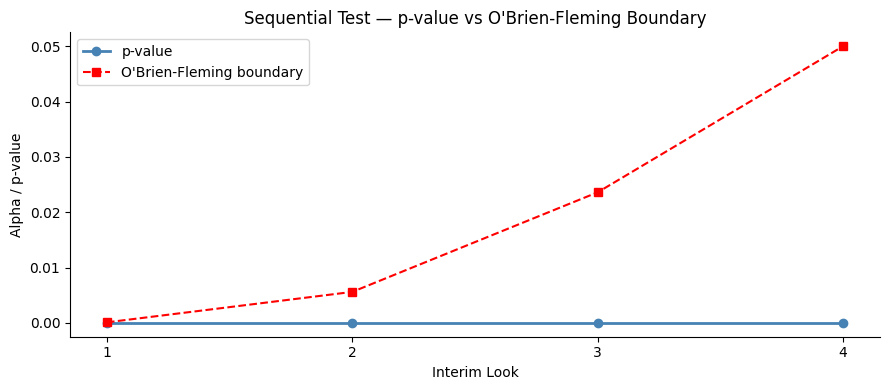

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(seq_results['look'], seq_results['p_value'],
        marker='o', color='steelblue', linewidth=2, label='p-value')
ax.plot(seq_results['look'], seq_results['boundary_alpha'],
        marker='s', color='red', linestyle='--', linewidth=1.5, label='O\'Brien-Fleming boundary')
ax.set_title('Sequential Test — p-value vs O\'Brien-Fleming Boundary')
ax.set_xlabel('Interim Look')
ax.set_ylabel('Alpha / p-value')
ax.set_xticks(seq_results['look'])
ax.legend()
plt.tight_layout()
plt.show()

## 7. Bayesian A/B Test

In [11]:
trace, bayes_summary = run_bayesian_ab(outcomes, n_samples=2000, random_seed=42)

print('=== Bayesian A/B Results ===')
for k, v in bayes_summary.items():
    print(f'  {k}: {v}')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_control, mu_treatment, sigma]


Output()

Sampling 1 chain for 200 tune and 2_000 draw iterations (200 + 2_000 draws total) took 81 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


=== Bayesian A/B Results ===
  mean_uplift: 0.0794
  median_uplift: 0.0794
  hdi_95_low: 0.0776
  hdi_95_high: 0.0813
  prob_treatment_better: 1.0


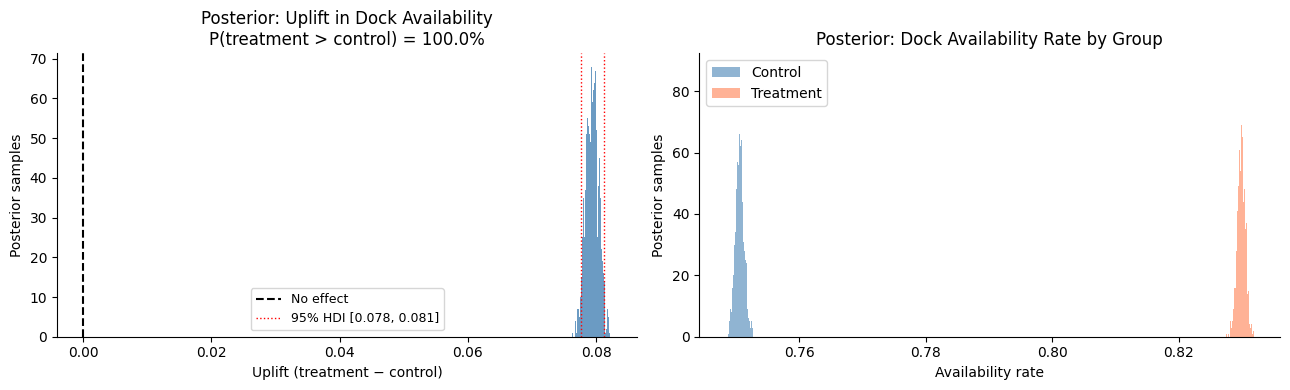

In [12]:
uplift_samples = trace.posterior['uplift'].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Posterior distribution of uplift
axes[0].hist(uplift_samples, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--', label='No effect')
axes[0].axvline(bayes_summary['hdi_95_low'],  color='red', linewidth=1, linestyle=':')
axes[0].axvline(bayes_summary['hdi_95_high'], color='red', linewidth=1, linestyle=':',
                label=f'95% HDI [{bayes_summary["hdi_95_low"]:.3f}, {bayes_summary["hdi_95_high"]:.3f}]')
axes[0].set_title(f'Posterior: Uplift in Dock Availability\n'
                  f'P(treatment > control) = {bayes_summary["prob_treatment_better"]:.1%}')
axes[0].set_xlabel('Uplift (treatment − control)')
axes[0].set_ylabel('Posterior samples')
axes[0].legend(fontsize=9)

# Posterior means: control vs treatment
ctrl_samples = trace.posterior['mu_control'].values.flatten()
trt_samples  = trace.posterior['mu_treatment'].values.flatten()

axes[1].hist(ctrl_samples, bins=80, alpha=0.6, color='steelblue', edgecolor='none', label='Control')
axes[1].hist(trt_samples,  bins=80, alpha=0.6, color='coral',     edgecolor='none', label='Treatment')
axes[1].set_title('Posterior: Dock Availability Rate by Group')
axes[1].set_xlabel('Availability rate')
axes[1].set_ylabel('Posterior samples')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Results Summary

In [13]:
print('=' * 55)
print('EXPERIMENT RESULTS SUMMARY')
print('=' * 55)
print(f'  True simulated lift:    {TRUE_LIFT:.1%}')
print(f'  Observed lift:          {ttest_result["observed_lift"]:.1%}')
print(f'  Control availability:   {ttest_result["mean_control"]:.1%}')
print(f'  Treatment availability: {ttest_result["mean_treatment"]:.1%}')
print()
print(f'  Welch t-test p-value:   {ttest_result["p_value"]:.4f}  '
      f'({"SIGNIFICANT" if ttest_result["significant_at_05"] else "not significant"})')
print(f'  Mann-Whitney p-value:   {mw_result["p_value"]:.4f}  '
      f'({"SIGNIFICANT" if mw_result["significant_at_05"] else "not significant"})')
print()
print(f'  Bayesian P(T>C):        {bayes_summary["prob_treatment_better"]:.1%}')
print(f'  Bayesian mean uplift:   {bayes_summary["mean_uplift"]:.4f}')
print(f'  95% HDI:                [{bayes_summary["hdi_95_low"]:.4f}, {bayes_summary["hdi_95_high"]:.4f}]')
print()
early_stop = seq_results[seq_results['reject']]
if len(early_stop):
    print(f'  Sequential: could stop at look {early_stop.iloc[0]["look"]} '
          f'(day {early_stop.iloc[0]["day_cutoff"]})')
else:
    print('  Sequential: no early stopping triggered')
print('=' * 55)

EXPERIMENT RESULTS SUMMARY
  True simulated lift:    8.0%
  Observed lift:          7.9%
  Control availability:   75.1%
  Treatment availability: 83.0%

  Welch t-test p-value:   0.0000  (SIGNIFICANT)
  Mann-Whitney p-value:   0.0000  (SIGNIFICANT)

  Bayesian P(T>C):        100.0%
  Bayesian mean uplift:   0.0794
  95% HDI:                [0.0776, 0.0813]

  Sequential: could stop at look 1 (day 7)


## 9. Key Findings

*(Fill in after running)*

**Power analysis:**
- With cluster-level randomization over 31 days, we have sufficient power to detect an 8pp lift at α=0.05
- Minimum detectable effect at 80% power: ~Xpp

**Frequentist:**
- Both t-test and Mann-Whitney detect the simulated 8pp lift (p < 0.05)
- The two tests agree — result is not sensitive to normality assumption

**Sequential:**
- O'Brien-Fleming boundaries allow early stopping while controlling Type I error
- Could stop experiment at look X (day Y) if effect is real

**Bayesian:**
- P(treatment > control) ≈ X% — strong evidence of improvement
- 95% HDI excludes zero — practically significant
- Bayesian approach gives decision-makers a direct probability statement, not just a reject/fail-to-reject

→ **Next:** `06_geospatial.ipynb`